# Data Append
Here to append all the data together and check how well hte pipeline worked

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

In [74]:
data2024 = pd.read_csv('clean_data/nov24pub_clean.csv')
data2022 = pd.read_csv('clean_data/nov22pub_clean.csv')
data2020 = pd.read_csv('clean_data/nov20pub_clean.csv')
data2018 = pd.read_csv('clean_data/nov18pub_clean.csv') 
data2016 = pd.read_csv('clean_data/nov16pub_clean.csv')
data2014 = pd.read_csv('clean_data/nov14pub_clean.csv')
data2012 = pd.read_csv('clean_data/nov12pub_clean.csv')
data2010 = pd.read_csv('clean_data/nov10pub_clean.csv')

In [75]:
data = data2024.copy()
data = pd.concat([data, data2022, data2020, data2018, data2016, data2014, data2012, data2010], ignore_index=True)

In [76]:
data

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,6,4,2
1,920760069071210,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,6,4,1
2,50057098511186,11,2024,1,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,9,4,1
3,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,-2,4,1
4,6110057715727,11,2024,2,201,NaN,1,1,1,-1,...,1,1,1,-1,-1,1,1,-2,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585066,893119280207301,11,2010,1,201,NaN,1,1,1,-1,...,NaN,1,1,-1,-1,1,1,8,6,NaN
585067,893119280207301,11,2010,1,201,NaN,1,1,1,-1,...,NaN,1,1,-1,-1,1,1,8,6,NaN
585068,893119280207301,11,2010,1,201,NaN,1,1,1,-1,...,NaN,1,1,-1,-1,1,1,8,6,NaN
585069,150007986516484,11,2010,1,201,NaN,1,1,1,-1,...,NaN,2,1,-1,11,-1,-1,-9,-9,NaN


In [77]:
data['HRYEAR4'].value_counts()

HRYEAR4
2012    81870
2014    80292
2016    79859
2010    78485
2018    72786
2020    68640
2024    62409
2022    60730
Name: count, dtype: int64

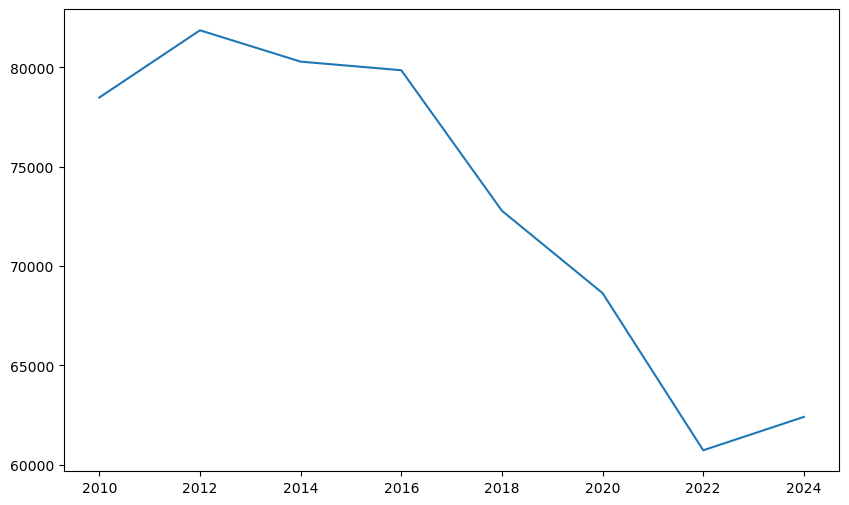

In [78]:
plt.figure(figsize=(10,6))
plt.plot(data['HRYEAR4'].value_counts().sort_index())

In [79]:
data[['PES1', 'PES2']].value_counts()

PES1  PES2
1     1       396665
2     2       102532
      1        85874
Name: count, dtype: int64

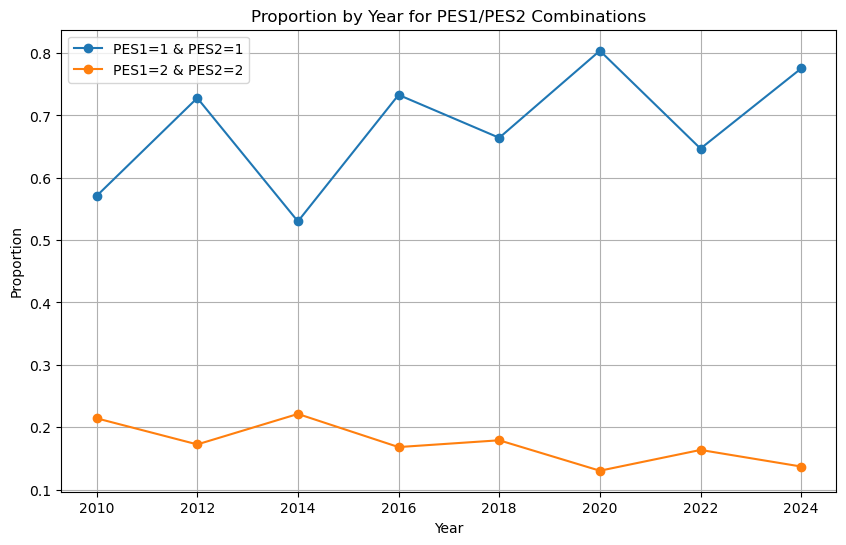

In [80]:
yearly = data.groupby('HRYEAR4').agg({
    'PES1': lambda d: ((d == 1) & (data.loc[d.index, 'PES2'] == 1)).mean(),
    'PES2': lambda d: ((d == 2) & (data.loc[d.index, 'PES1'] == 2)).mean()
}).rename(columns={'PES1': 'pes1_1_pes2_1', 'PES2': 'pes1_2_pes2_2'}).sort_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly.index, yearly['pes1_1_pes2_1'], marker='o', label='PES1=1 & PES2=1')
plt.plot(yearly.index, yearly['pes1_2_pes2_2'], marker='o', label='PES1=2 & PES2=2')
plt.xticks(yearly.index)
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.title('Proportion by Year for PES1/PES2 Combinations')
plt.legend()
plt.grid(True)

In [81]:
data['PWSSWGT'].value_counts(dropna=False)

PWSSWGT
27065875    31
24300072    29
14667054    27
26496185    26
29070464    26
            ..
32159242     1
48648816     1
42368387     1
30036027     1
9766914      1
Name: count, Length: 321564, dtype: int64

In [116]:
print(data.groupby('HRYEAR4')['PES1'].count())#.value_counts(dropna =False)
#Need to look at 2010 PRTAGE, 2010 PEEDUCA, 2010 - 2014 GEDIV, 
data.groupby('HRYEAR4')['PES1'].value_counts(dropna =False)


HRYEAR4
2010    78485
2012    81870
2014    80292
2016    79859
2018    72786
2020    68640
2022    60730
2024    62409
Name: PES1, dtype: int64


HRYEAR4  PES1
2010     1       44802
         2       33683
2012     1       59597
         2       22273
2014     1       42559
         2       37733
2016     1       58533
         2       21326
2018     1       48337
         2       24449
2020     1       55170
         2       13470
2022     1       39280
         2       21450
2024     1       48387
         2       14022
Name: count, dtype: int64

In [48]:
pd.options.display.float_format = '{:,.0f}'.format
data.groupby('HRYEAR4')['PWSSWGT'].sum() / 1000
#Find Weight Names for 2012 and 2014, and make the column names are conveying the same idea.

HRYEAR4
2010   1,739,561,635
2012   1,852,231,246
2014   1,809,448,027
2016   1,890,909,355
2018   1,851,602,600
2020   1,932,193,689
2022   1,916,794,728
2024   2,004,782,700
Name: PWSSWGT, dtype: float64

In [49]:
data['PES1'].value_counts(dropna=False)

PES1
1    396665
2    188406
Name: count, dtype: int64

In [50]:
data['GEDIV'].value_counts(dropna=False)

GEDIV
NaN    240647
5       62940
9       47156
8       43924
3       37977
7       37093
4       33431
2       28765
1       27276
6       25862
Name: count, dtype: int64

In [32]:
data['PESEX'].value_counts()

PESEX
2    307757
1    277314
Name: count, dtype: int64

In [36]:
data['PEEDUCA'].value_counts(dropna=False).head(30)

PEEDUCA
39     146860
43     109165
40      93620
NaN     78485
44      46350
42      30182
41      23920
37      10609
46       9287
45       7480
36       7319
38       6254
34       6108
35       4950
33       2486
32       1282
31        714
Name: count, dtype: int64

In [72]:
with open("txt_files/cpsnov10.txt") as f:
    lines = f.readlines()
matches = [line for line in lines if 'PEEDUCA' in line]
for line in matches:
    print(repr(line))

'\x0cPEEDUCA    2   HIGHEST LEVEL OF SCHOOL                       137 - 138\n'
'                  PEEDUCA = 39\n'
'                  PEEDUCA =40-42\n'
'                  PEEDUCA = 43\n'
'                  PEEDUCA = 44\n'
